# __Symmetry analysis. Pysical adequacy__

## __Model definitions__

In [2]:
# ANI


# import the calculators
from torch import device
from torchani.models import ANI1x, ANI2x, ANI1ccx

ani1x_calc = ANI1x().ase()
ani1ccx_calc = ANI1ccx().ase()
ani2x_calc = ANI2x().ase()

# device type can defined via torch and parsed to the model via .to() method
#device_ = device('cpu')
#model_ = ANI1x(periodic_table_index=True).to(device_).double().ase()


# MACE
from mace.calculators import mace_mp, mace_off

macemp = mace_mp(
    model="medium", 
    dispersion=False, 
    default_dtype="float32", 
    device='cpu',
    )

maceoff = mace_off(
    model="medium", 
    device='cpu',
    default_dtype='float32'
    )

# ORB

from orb_models.forcefield.pretrained import orb_v2, orb_d3_v2
from orb_models.forcefield.calculator import ORBCalculator

orbff_v2 = orb_v2(device='cpu')
orb_calc_v2 = ORBCalculator(orbff_v2, device='cpu')

orbff_d3_v2 = orb_d3_v2(device='cpu')
orb_calc_d3_v2 = ORBCalculator(orbff_d3_v2, device='cpu')


CALC_NAME = 'ALL'

/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/aev.py:16: UserWarning: cuaev not installed
  warnings.warn("cuaev not installed")


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/
/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/
/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indice

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /Users/sergiortizropero/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.
Using MACE-OFF23 MODEL for MACECalculator with /Users/sergiortizropero/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=model_p

In [21]:
# ORB
from orb_models.forcefield.pretrained import orb_v2, orb_d3_v2, orb_v3_conservative_inf_omat, orb_v3_direct_inf_omat
from orb_models.forcefield.calculator import ORBCalculator

orbff_v2 = orb_v2(device='cpu')
orb_calc_v2 = ORBCalculator(orbff_v2, device='cpu')

orbff_d3_v2 = orb_d3_v2(device='cpu')
orb_calc_d3_v2 = ORBCalculator(orbff_d3_v2, device='cpu')

orbff_v3_conserv = orb_v3_conservative_inf_omat(device='cpu')
orbff_v3_conserv_calc = ORBCalculator(orbff_v3_conserv, device='cpu')

orbff_v3_noconserv = orb_v3_direct_inf_omat(device='cpu')
orbff_v3_noconserv_calc = ORBCalculator(orbff_v3_noconserv, device='cpu')


CALC_NAME = 'ORB'

/Users/sergiortizropero/miniconda3/envs/ASE_orbital/lib/python3.10/site-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


In [1]:
# UMA
from fairchem.core import FAIRChemCalculator
from fairchem.core.units.mlip_unit import load_predict_unit

# define the UMA ASE calculator
uma_predictor = load_predict_unit(
    path='/Users/sergiortizropero/TFG_phys/NNPs_TFG/models/ase_uma/uma-s-1p1.pt', 
    device='cpu',                   
    inference_settings='default',   
)
uma_calc = FAIRChemCalculator(
    uma_predictor,
    task_name='omol',               
)

CALC_NAME = 'UMA'

/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/torchtnt/utils/version.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
W0718 11:51:27.198000 84253 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
# define the calculators
calculator_list = [ani1x_calc, ani1ccx_calc, ani2x_calc, macemp, maceoff, orb_calc_v2, orb_calc_d3_v2]
calculator_names = ['ANI-1x', 'ANI-1ccx', 'ANI-2x', 'MACE-MP', 'MACE-OFF', 'ORB-V2', 'ORB-D3-V2']
calculator_colors = ['darkviolet', 'crimson', 'deeppink', 'darkgreen', 'mediumseagreen', 'royalblue', 'darkblue']

color_dict = {
    'ANI-1x': 'darkviolet', 
    'ANI-1ccx': 'crimson', 
    'ANI-2x': 'deeppink', 
    'MACE-MP': 'darkgreen', 
    'MACE-OFF':  'mediumseagreen', 
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
}

In [2]:
# define the calculators
calculator_list = [uma_calc]
calculator_names = ['UMA_small']
calculator_colors = ['black']

color_dict = {
    'UMA_small': 'black', 
}

In [22]:
# define the calculators
calculator_list = [orb_calc_v2, orb_calc_d3_v2, orbff_v3_conserv_calc, orbff_v3_noconserv_calc]
calculator_names = ['ORB-V2', 'ORB-D3-V2', 'ORB-V3', 'ORB-V3-direct']
calculator_colors = ['royalblue', 'darkblue', 'deeppink', 'crimson']

#calculator_list = [orbff_v3_conserv_calc, orbff_v3_noconserv_calc]
#calculator_names = ['ORB-V3', 'ORB-V3-direct']
#calculator_colors = ['crimson', 'darkblue']

color_dict = {
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
    'ORB-V3': 'red', 
    'ORB-V3-direct': 'maroon',
}

## __Imports & Functions__

In [4]:
# general imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
rc('lines', lw=1, color='b')
rc('legend', loc='best')
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.edgecolor"] = 'black'
plt.rcParams['legend.borderpad'] = 0.25
plt.rcParams['legend.fontsize'] = 11
plt.rcParams.update({'pgf.preamble': r'\usepackage{amsmath}'})

from ase import Atoms
from ase.visualize import view
from ase.build import molecule
from ase.io import write, read
from ase.io import Trajectory, trajectory
from ase import build
from ase.data.pubchem import pubchem_atoms_search

In [5]:
def torque(positions, forces):
    torques = []
    for position, force in zip(positions, forces):
        tau = np.cross(position, force)
        torques.append(tau)
    total_torque = np.array(torques).sum()
    return total_torque


def compute_com_torque(atoms, calculator):
    '''
    Compute the total internal torque wrt the center of mass of the molecule
    Note that the total tau is invariant wrt the change of coordinate system. 
    '''
    
    # copy the object (just to be safe)
    molecule = atoms.copy()
    molecule.calc = calculator

    molecule.info = {"charge": 0, "spin": 1} 

    # get center of mass
    com = molecule.get_center_of_mass()
    #print(f'initial com\t{com}')

    # get initial torque
    pos = np.array(molecule.get_positions())
    forces = np.array(molecule.get_forces())
    torques = torque(pos, forces)
    
    #print(f'total torque\t{torques}')

    # substract com to "center" the molecule
    #cur_pos = np.array(molecule.positions)
    #new_pos = cur_pos - com
    #molecule.positions = new_pos

    # get new center of mass
    #com_final = molecule.get_center_of_mass()
    #print(f'final com\t{com_final}')

    # get final torque
    #pos_prime = np.array(molecule.get_positions())
    #forces_prime = np.array(molecule.get_forces())
    #torques_prime = torque(pos_prime, forces_prime)
    #print(f'final torque\t{torques}')

    #return torques_prime
    return torques


def funct_compute_angle(cosan):
    '''
    Compute the real COSAN angle using a custom metric. This is approximated as:

    - Obtain position of terminal B atoms () 
    '''

    # copy molecule object
    mol = cosan.copy()
    dih = mol.get_dihedral(8, 4, 15, 19)

    # top and bottom B atoms, to serve as axis
    B_up_pointy = cosan.get_positions()[4]
    B_down_pointy = cosan.get_positions()[15]

    # opposite B atoms wrt to C atoms in each ligand, to seve as dihedrals
    B_up_pentagon = cosan.get_positions()[8]
    B_down_pentagon = cosan.get_positions()[19]

    # compute the dihedral C_up C_down along the B_up - B_down axis
    # if this angle is small: cis (C regions overlap)

    return dih

    
    


In [9]:
def evaluate_rotation(mol, calculator_list, mol_name, calc_name, verbose=False, rot_angle='z', visualize=False, group=[], compute_torque=True, cosan=False, resolution=None, linewidth=1, UMA=False, load_UMA=False, kJ=False, print_plot_energies=False, charge=0, spin=1, compute_angle=False, save_txt=False):

    molecule = mol.copy()
    molecule.info = {"charge": charge, "spin": spin} 

    # create the working directory
    work_dir = os.path.join(os.curdir, 'symmetries',  mol_name)
    if not os.path.isdir(work_dir):
        os.makedirs(work_dir)

    # define the trajectory file and path
    if len(calculator_list) == 1:
        traj_path = os.path.join(work_dir, f'{mol_name}_{calc_name}_rotation.traj')
        traj = trajectory.TrajectoryWriter(filename=traj_path, mode='w', properties=['energy'])

    # fixed resolution
    if resolution is not None:
        delta_angle = resolution
    else: 
        delta_angle = 6.
    points = int(360./delta_angle)
    angles = np.linspace(0., 360., points+1)

    # print a description of the calculation
    print(f'{mol_name}')
    print(f'analyzing {points} rotationally different structures')
    print(f'using {len(calculator_list)} models')
    print(f'scanning angles:\n{angles}\n')
    
    # initiate a .txt to store the max fluctuations
    fluctuation_path = os.path.join('./symmetries',mol_name,f'{mol_name}_rotation_fluctuations')+'.txt'
    with open(fluctuation_path, 'w') as f:
        f.write(f'# rotation results for {mol_name}\n')
        f.write(f'# MODEL\t\t\tMAX E\t\t\tMAX F\t\t\tMAX tau\n')
    
    # save UMA model data in a separate folder to plot all models (dependency issue)
    uma_file_name = os.path.join('./symmetries',mol_name,f'{mol_name}_UMA_small_data_rotations')+'.txt'
    uma_loaded = False

    # compute rotation energies, forces and torques
    energies = []
    forces = []
    torques = []
    sucessful_calcs = []
    if compute_angle:
        real_angle_list = []

    k = 0
    for calc_ in calculator_list:
        k += 1

        #try:

        molecule.calc = calc_
        
        calc_energy_list = []
        calc_force_list = []
        calc_torque_list = []

        for angle in angles:

            # compute real angle first
            if compute_angle:
                real_angle_list.append(funct_compute_angle(cosan=molecule))

            energy_ = molecule.get_potential_energy()
            force = np.array(molecule.get_forces())
            f_vec = force.sum(axis=0)
            f_scalar = np.sqrt(f_vec.dot(f_vec))
            if compute_torque:
                calc_torque_list.append(compute_com_torque(molecule, calc_))
            
            if kJ:
                calc_energy_list.append(energy_ * 96.48530749925794)
            else:
                calc_energy_list.append(energy_)
            calc_force_list .append(f_scalar)
            
            #if verbose:
            #    print(f'energy ({angle:.0f} deg)\t{energy_}')
            
            if len(calculator_list) == 1:
                traj.write(molecule)

            if len(group) == 0:
                molecule.rotate(delta_angle, rot_angle)
            
            else:
                # perform a group rotation
                subsys = molecule[group]
                subsys.rotate(rot_angle, delta_angle, rotate_cell = False)
                molecule.positions[group] = subsys.positions

        # define relative fluctuations (substracting the minimum)
        idx = np.argmin(calc_energy_list[:])
        min_energy = calc_energy_list[idx]
        corrected_energy = (np.array(calc_energy_list[:]) - min_energy)
    
        idx_ = np.argmin(calc_force_list[:])
        min_force = calc_force_list[idx_]
        corrected_force = np.array(calc_force_list[:]) - min_force

        if compute_torque:
            idx__ = np.argmin(calc_torque_list[:])
            min_torque = calc_force_list[idx__]
            corrected_torque = np.array(calc_torque_list[:]) - min_torque

        # analysis of each calculator
        idx_energy = np.argmax(corrected_energy)
        idx_force = np.argmax(corrected_force)
        if compute_torque:
            idx_torque = np.argmax(np.array(calc_torque_list[:])-min_torque)
            with open(fluctuation_path, 'a') as f:
                f.write(f'{(calculator_names[k-1])}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\t{corrected_torque[idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\n')

        # save
        energies.append(calc_energy_list)
        forces.append(calc_force_list)
        if compute_torque:
            torques.append(calc_torque_list)

        sucessful_calcs.append(calculator_names[k-1])

        # export raw data of UMA to a .txt file
        if UMA:
            if calc_ == uma_calc:
                with open(file=uma_file_name, mode='w') as f:
                    f.write(f'# UMA data for molecule: {mol_name}\n')
                    f.write(f'# z-axis rotation with {points} rotamers and resolution {resolution}\n')
                    f.write(f'# ENERGY\t\tFORCES\t\tTORQUE (if exists)\n')
                    if compute_torque:
                        for i in range(len(calc_energy_list)):
                            f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\t{corrected_torque[i]}\n')
                    else:
                        for i in range(len(calc_energy_list)):
                            f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\n')
                    
        #except: 
            print(f'CALCULATOR {calculator_names[k-1]} FAILED')

        # visualize the "trajectory" using the built-in ASE visualizer
        if visualize:
            if len(calculator_list) == 1:
                traj = trajectory.TrajectoryReader(traj_path)
                view(traj, viewer='ase')

    #print(f'resulting energies:\n{energies}')
    #print(f'resulting forces (total, scalar):\n{force}')

    # load UMA data, must be obtained in a preprocessing step 
    #if os.path.exists(fluctuation_path): 
    if (not UMA) and os.path.exists(uma_file_name):
        print('loading UMA')
        uma_data = np.loadtxt(delimiter='\t', dtype='float', fname=uma_file_name)
        energies.append(uma_data[:,0])
        forces.append(uma_data[:,1])
        if compute_torque:
            torques.append(uma_data[:,2])
        if load_UMA:
            uma_loaded = True

        # analyze UMA data and append it to the rest 
        idx_energy = np.argmax(uma_data[:,0])
        idx_force = np.argmax(uma_data[:,1])
        if compute_torque:
            idx_torque = np.argmax(uma_data[:,2])
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\t{uma_data[:,2][idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\n')

    # plot the energies
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    
    if cosan:
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")
        ax_twin = plt.twinx(ax)
        ax_twin.tick_params(bottom=False, top=False, left=False, right=True, direction="in")
        ax_twin.tick_params(labelbottom=False, labeltop=False, labelleft=False, labelright=True, direction="in")
        
        plots = []
        for k in range(len(sucessful_calcs)):
            idx = np.argmin(energies[k][:])
            min_energy = energies[k][idx]


            if k == 0:
                p = ax.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=1.0, lw=2)
                plots.append(p)
            else:
                p = ax_twin.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.6)
                plots.append(p)

            ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV) (\textbf{MACE})}$')
            ax_twin.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV) (\textbf{ORB})}$')

        plots_sum = plots[0]+plots[1]+plots[2]
        labs = [p.get_label() for p in plots_sum]
        ax_twin.legend(plots_sum, labs, loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})


    else:
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")
        
        for k in range(len(sucessful_calcs)):
            idx = np.argmin(energies[k][:])
            min_energy = energies[k][idx]

            if verbose:
                to_print = np.array(energies[k][:])-min_energy

                for m in range(len(energies[k])):
                    if compute_angle:
                        print(f'Angle\t{angles[m]:.1f}\t|\tReal\t{(real_angle_list[m]):.1f}\t|\tEnergy\t{to_print[m]:.2f}')
                    else:
                        print(f'Angle\t{angles[m]:.1f}\t|\tEnergy\t{to_print[m]:.2f}')

            if print_plot_energies:
                print(np.array(energies[k][:])-min_energy) 

            if compute_angle:         
                ax.plot(real_angle_list, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.8, lw=linewidth)
                with open(os.path.join(work_dir, f'{mol_name}_{calc_name}_energy_rotation.txt'), 'w') as f:
                    for i in range(len(real_angle_list)):
                        f.write(f'{real_angle_list[i]}\t{(np.array(energies[k][:])-min_energy)[i]}\n')
                          
            else:
                ax.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.8, lw=linewidth)

        # add UMA data to the plot
        if uma_loaded:
            idx = np.argmin(energies[-1][:])
            min_energy = energies[-1][idx]
            ax.plot(angles, np.array(energies[-1][:])-min_energy, label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.8, lw=linewidth)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        if kJ:
            ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad(\textnormal{kJ mol}^{-1})$')
        else:
            ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-5, 1e-5)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_energy_rotation.png'), dpi=400)
    plt.show(fig)


    # plot the forces
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(forces[k][:])
        min_energy = forces[k][idx]
        ax.plot(angles, (np.array(forces[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    if uma_loaded:
        idx = np.argmin(forces[-1][:])
        min_force = forces[-1][idx]
        ax.plot(angles, (np.array(forces[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\textnormal{Total forces}\quad\textnormal{(eV/Å)}$')
    # workaround only to avoid displaying very small numbers (truncation errors)
    #ax.set_ylim(-1e-5, 1e-5)
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_forces_rotation.png'), dpi=400)
    plt.show(fig)



    # plot the torques
    if compute_torque:
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

        for k in range(len(sucessful_calcs)):
            idx = np.argmin(torques[k][:])
            min_energy = torques[k][idx]
            ax.plot(angles, (np.array(torques[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

        if uma_loaded:
            print(torques[-1])
            idx = np.argmin(torques[-1][:])
            min_force = torques[-1][idx]
            ax.plot(angles, (np.array(torques[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\textnormal{Total torque}\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-10, 1e-10)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
        
        plt.tight_layout()
        plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_torque_rotation.png'), dpi=400)
        plt.show(fig)   

In [7]:
def evaluate_translation(mol, calculator_list, mol_name, calc_name, verbose=False, trans_vector=(0,0,1), resolution=0.1, search_space=[-10, 10], visualize=False, compute_torque=True, UMA=False, load_UMA=False, charge=0, spin=1):
    '''
    trans_vector is converted to unitary prior to application!!! (1A displacement resolution)
    search_space is the translation coordinates to explore at `resolution` Å steps
    '''

    molecule = mol.copy()
    molecule.info = {"charge": charge, "spin": spin} 

    # create the working directory
    work_dir = os.path.join(os.curdir, 'symmetries',  mol_name)
    if not os.path.isdir(work_dir):
        os.makedirs(work_dir)

    # define the trajectory file and path
    if len(calculator_list) == 1:
        traj_path = os.path.join(work_dir, f'{mol_name}_{calc_name}_translation.traj')
        traj = trajectory.TrajectoryWriter(filename=traj_path, mode='w')
        
    # compute the unit translation vector 
    vec = np.array(trans_vector)
    unit_transl_vector = vec / (np.sqrt(vec.dot(vec)))

    # adjust for resolution 
    scaled_transl_vector = unit_transl_vector * resolution
    displacements = np.arange(search_space[0], search_space[1]+resolution, step=resolution)

    # print a description of the calculation
    print(f'using unit translation vector\t{unit_transl_vector}')
    print(f'analyzing translationally different structures with resolution {resolution} Å')
    print(f'using {len(calculator_list)} models')
    print(f'scanning total displacements:\n{displacements}')
    
    # initiate a .txt to store the max fluctuations
    fluctuation_path = os.path.join('./symmetries',mol_name,f'{mol_name}_translation_fluctuations')+'.txt'
    with open(fluctuation_path, 'w') as f:
        f.write(f'# translation results for {mol_name}\n')
        f.write(f'# MODEL\t\t\tMAX E\t\t\tMAX F\t\t\tMAX tau\n')
    
    # save UMA model data in a separate folder to plot all models (dependency issue)
    uma_file_name = os.path.join('./symmetries',mol_name,f'{mol_name}_UMA_small_data_translations')+'.txt'
    uma_loaded = False


    # compute translation energies, forces and torques
    energies = []
    forces = []
    torques = []
    sucessful_calcs = []
    

    k = 0
    for calc_ in calculator_list:
        k += 1

        #try:
        molecule.calc = calc_
        calc_energy_list = []
        calc_force_list = []
        calc_torque_list = []

        for displacement in displacements:
            
            energy_ = molecule.get_potential_energy()
            force = np.array(molecule.get_forces())
            f_vec = force.sum(axis=0)
            f_scalar = np.sqrt(f_vec.dot(f_vec))
            if compute_torque:
                calc_torque_list.append(compute_com_torque(molecule, calc_))
            calc_energy_list.append(energy_)
            calc_force_list .append(f_scalar)
            
            if verbose:
                print(f'energy ({displacement:.0f} Å)\t{energy_}')
            
            if len(calculator_list) == 1:
                traj.write(molecule)

            molecule.translate(scaled_transl_vector)
        
        # define relative fluctuations (substracting the minimum)
        idx = np.argmin(calc_energy_list[:])
        min_energy = calc_energy_list[idx]
        corrected_energy = np.array(calc_energy_list[:]) - min_energy
    
        idx_ = np.argmin(calc_force_list[:])
        min_force = calc_force_list[idx_]
        corrected_force = np.array(calc_force_list[:]) - min_force

        if compute_torque:
            idx__ = np.argmin(calc_torque_list[:])
            min_torque = calc_force_list[idx__]
            corrected_torque = np.array(calc_torque_list[:]) - min_torque

        # analysis of each calculator
        idx_energy = np.argmax(corrected_energy)
        idx_force = np.argmax(corrected_force)
        if compute_torque:
            idx_torque = np.argmax(np.array(calc_torque_list[:])-min_torque)
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\t{corrected_torque[idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\n')

        # save 
        energies.append(corrected_energy)
        forces.append(corrected_force)
        if compute_torque:
            torques.append(corrected_torque)

        sucessful_calcs.append(calculator_names[k-1])

        # export raw data of UMA to a .txt file
        if UMA:
            with open(file=uma_file_name, mode='w') as f:
                f.write(f'# UMA data for molecule: {mol_name}\n')
                f.write(f'# translation direction {unit_transl_vector} with resolution {resolution} and {len(displacements)} displacements\n')
                f.write(f'# ENERGY\t\tFORCES\t\tTORQUE (if exists)\n')
                if compute_torque:
                    for i in range(len(calc_energy_list)):
                        f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\t{corrected_torque[i]}\n')
                else:
                    for i in range(len(calc_energy_list)):
                        f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\n')
                
        #except: 
            #print(f'CALCULATOR {calculator_names[k-1]} FAILED')
        
        # visualize the "trajectory" using the built-in ASE visualizer
        if visualize:
            if len(calculator_list) == 1:
                traj = trajectory.TrajectoryReader(traj_path)
                view(traj, viewer='ase')

    #print(f'resulting energies:\n{energies}')
    #print(f'resulting forces (total, scalar):\n{force}')

    # load UMA data, must be obtained in a preprocessing step 
    #if os.path.exists(fluctuation_path): 
    if (not UMA) and os.path.exists(uma_file_name):
        print('loading UMA')
        uma_data = np.loadtxt(delimiter='\t', dtype='float', fname=uma_file_name)
        energies.append(uma_data[:,0])
        forces.append(uma_data[:,1])
        if compute_torque:
            torques.append(uma_data[:,2])
        if load_UMA:
            uma_loaded = True

        # analyze UMA data and append it to the rest 
        idx_energy = np.argmax(uma_data[:,0])
        idx_force = np.argmax(uma_data[:,1])
        if compute_torque:
            idx_torque = np.argmax(uma_data[:,2])
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\t{uma_data[:,2][idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\n')

    # plot the energies
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(energies[k][:])
        min_energy = energies[k][idx]
        ax.plot(displacements, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    # add UMA data to the plot
    if uma_loaded:
        idx = np.argmin(energies[-1][:])
        min_energy = energies[-1][idx]
        ax.plot(displacements, np.array(energies[-1][:])-min_energy, label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\Delta E\quad\textnormal{(eV)}$')
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_energies_translation.png'), dpi=400)
    plt.show(fig)


    # plot the forces
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(forces[k][:])
        min_energy = forces[k][idx]
        ax.plot(displacements, (np.array(forces[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    if uma_loaded:
        idx = np.argmin(forces[-1][:])
        min_force = forces[-1][idx]
        ax.plot(displacements, (np.array(forces[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\textnormal{Total forces}\quad\textnormal{(eV/Å)}$')
    # workaround only to avoid displaying very small numbers (truncation errors)
    #ax.set_ylim(-1e-10, 1e-10)
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_forces_translation.png'), dpi=400)
    plt.show(fig)


    # plot the torques
    if compute_torque:

        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

        for k in range(len(sucessful_calcs)):
            idx = np.argmin(torques[k][:])
            min_energy = torques[k][idx]
            ax.plot(displacements, (np.array(torques[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

        if uma_loaded:
            print(torques[-1])
            idx = np.argmin(torques[-1][:])
            min_force = torques[-1][idx]
            ax.plot(displacements, (np.array(torques[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\textnormal{Total torque}\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-10, 1e-10)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
        
        plt.tight_layout()
        plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_torques_translation.png'), dpi=400)
        plt.show(fig)  


## __COSAN rigid scan PES__

In [ ]:
# use ALL previously defined calculators
mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)
CALC_NAME='ALL'

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=True, group=group, compute_torque=False, cosan=True, resolution=2)

cosan
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

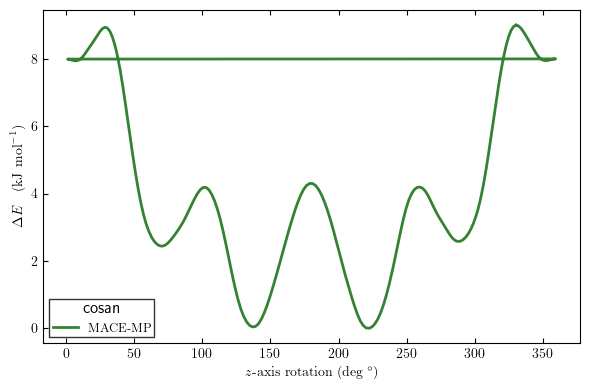

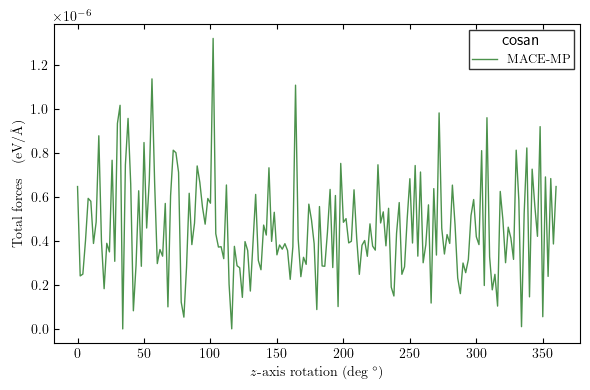

In [10]:
# MACE-MP-0 only
calculator_list = [macemp]
calculator_names = ['MACE-MP']
CALC_NAME='MACE-MP'

mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=False, group=group, compute_torque=False, cosan=False, resolution=2, linewidth=2, kJ=True, print_plot_energies=True, compute_angle=True, save_txt=True)


cosan
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

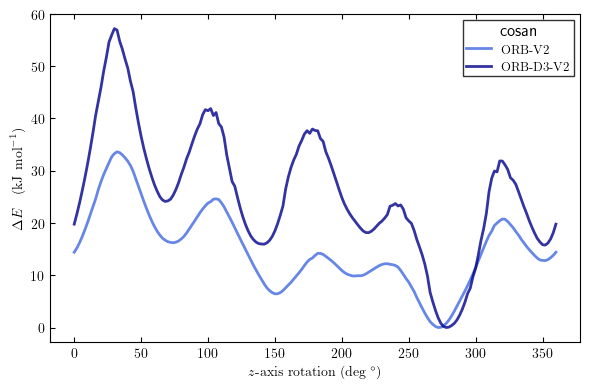

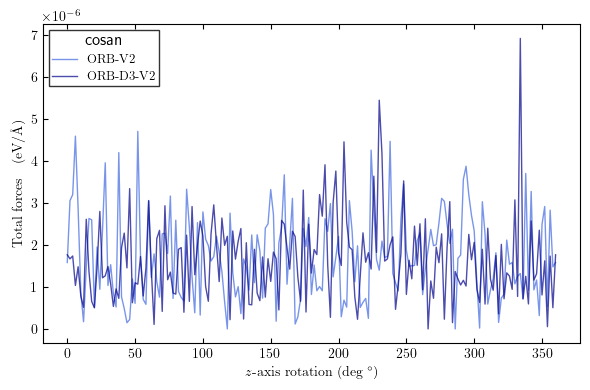

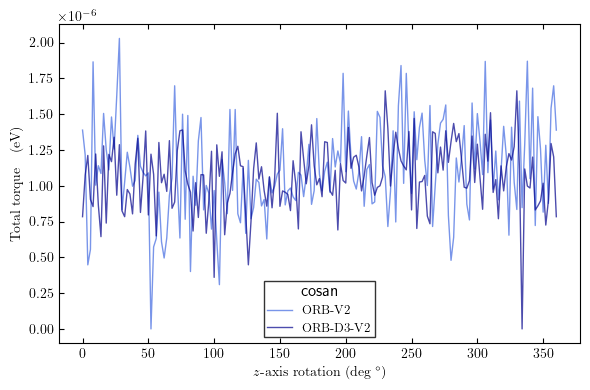

In [8]:
# ORB-V2 models only
calculator_list = [orb_calc_v2, orb_calc_d3_v2]
calculator_names = ['ORB-V2', 'ORB-D3-V2']
CALC_NAME='ORB'

mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=False, group=group, compute_torque=True, cosan=False, resolution=2, linewidth=2, kJ=True)

cosan
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

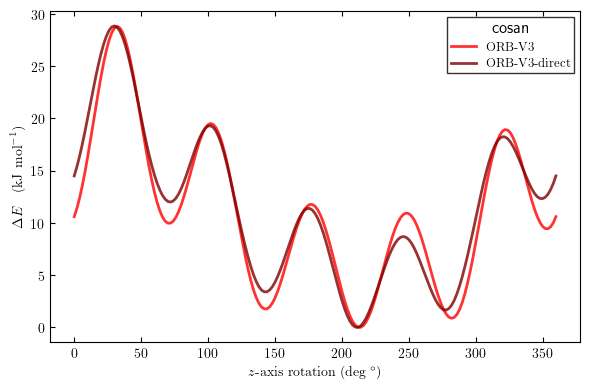

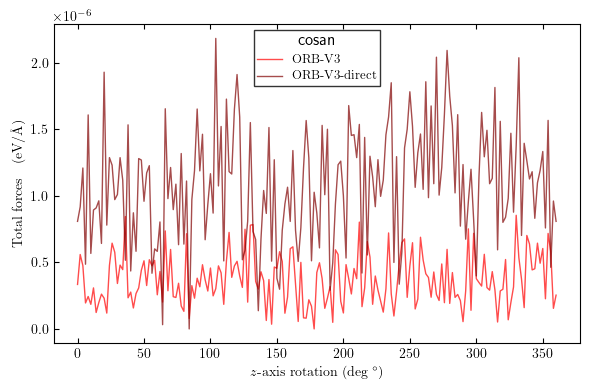

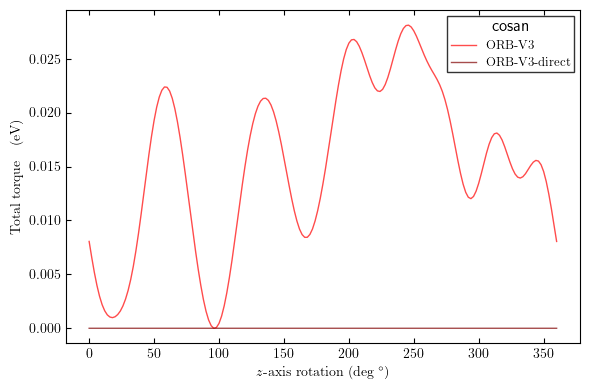

In [29]:
# ORB-V3 models only (OMat24)
calculator_list = [orbff_v3_conserv_calc, orbff_v3_noconserv_calc]
calculator_names = ['ORB-V3', 'ORB-V3-direct']
CALC_NAME='ORB-V3'

mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=False, group=group, compute_torque=True, cosan=False, resolution=2, linewidth=2, kJ=True)

cosan
analyzing 100 rotationally different structures
using 1 models
scanning angles:
[  0.    3.6   7.2  10.8  14.4  18.   21.6  25.2  28.8  32.4  36.   39.6
  43.2  46.8  50.4  54.   57.6  61.2  64.8  68.4  72.   75.6  79.2  82.8
  86.4  90.   93.6  97.2 100.8 104.4 108.  111.6 115.2 118.8 122.4 126.
 129.6 133.2 136.8 140.4 144.  147.6 151.2 154.8 158.4 162.  165.6 169.2
 172.8 176.4 180.  183.6 187.2 190.8 194.4 198.  201.6 205.2 208.8 212.4
 216.  219.6 223.2 226.8 230.4 234.  237.6 241.2 244.8 248.4 252.  255.6
 259.2 262.8 266.4 270.  273.6 277.2 280.8 284.4 288.  291.6 295.2 298.8
 302.4 306.  309.6 313.2 316.8 320.4 324.  327.6 331.2 334.8 338.4 342.
 345.6 349.2 352.8 356.4 360. ]

Angle	0.0	|	Real	330.3	|	Energy	13.11
Angle	3.6	|	Real	333.6	|	Energy	14.71
Angle	7.2	|	Real	336.9	|	Energy	16.85
Angle	10.8	|	Real	340.2	|	Energy	19.41
Angle	14.4	|	Real	343.4	|	Energy	22.21
Angle	18.0	|	Real	346.7	|	Energy	25.04
Angle	21.6	|	Real	349.9	|	Energy	27.63
Angle	25.2	|	Real	353.2	|	Ene

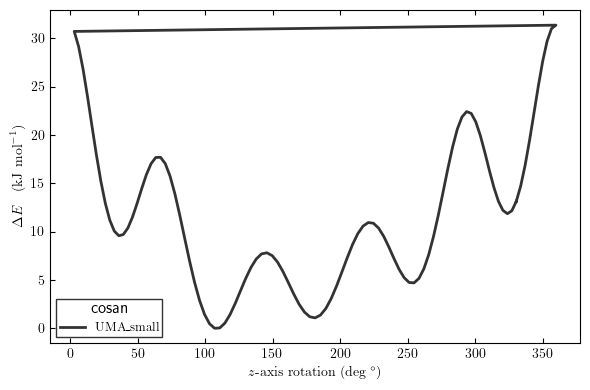

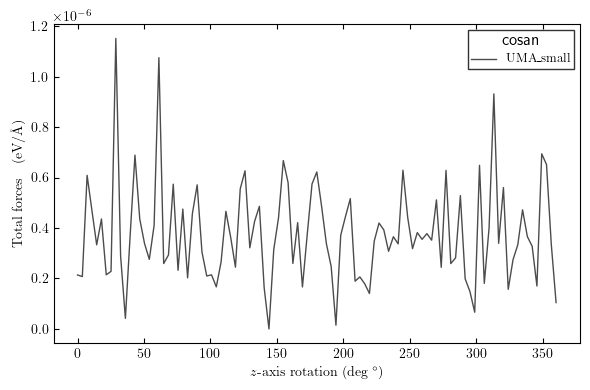

In [ ]:
# UMA small model only
calculator_list = [uma_calc]
calculator_names = ['UMA_small']
CALC_NAME='UMA_small'


# SIMULATION PARAMETERS
mol_name = 'cosan'
charge_cosan = -1
spin_cosan = 3
resolution_cosan = 3.6

cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)


group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(
    cosan,
    calculator_list, 
    calc_name=CALC_NAME, 
    mol_name=mol_name, 
    visualize=False, 
    group=group, 
    compute_torque=False, 
    cosan=False, 
    resolution=resolution_cosan, 
    linewidth=2, 
    kJ=True, 
    print_plot_energies=False, 
    charge=charge_cosan, 
    spin=spin_cosan,
    verbose=True, 
    compute_angle=True
)



In [35]:
# visualize any existent trajectory
path = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan_UMA_small_rotation_-1_3.traj'
traj = Trajectory(path)
view(traj, viewer='ase')

<Popen: returncode: None args: ['/Users/sergiortizropero/miniconda3/envs/ASE...>

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/matplotlib/pyplot.py", line 614, in show
    return _get_backend_mod().show(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/IPython/core/display_functions.py", line 245, in display
    print(*objs)
ValueError: I/O operati

## __COSAN soft scan__



In [ ]:

def unit_vector(vector):
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)) * 360. / (2*np.pi)




def cosan_angle(cosan):
    c_11 = cosan.get_positions()[11][:2]
    c_0 = cosan.get_positions()[0][:2]
    return angle_between(c_0, c_11)

def funct_compute_angle(cosan):
    '''
    Compute the real COSAN angle using a custom metric. This is approximated as:

    - Obtain position of terminal B atoms () 
    '''

    # top and bottom B atoms, to serve as axis
    B_up_pointy = cosan.get_positions()[4]
    B_down_pointy = cosan.get_positions()[15]

    # opposite B atoms wrt to C atoms in each ligand, to seve as dihedrals
    B_up_pentagon = cosan.get_positions()[8]
    B_down_pentagon = cosan.get_positions()[19]

    # compute the dihedral C_up C_down along the B_up - B_down axis
    # if this angle is small: cis (C regions overlap)



def cosan_soft_scan(calculator, CALC_NAME, resolution=None, precision=0.05, visualize=False, use_true_angle=False, charge=1, spin=0, compute_angle=False):

    '''
    - Define the calculator
    - Define directories
    - Define the molecule and attributes
    - Center COSAN structure such that Co is at 0,0,0
    - Define the C-C angle
    - At each step of the rotation
        - Define constraints
            - Co and C,C,C,C must remain fixed
        - Perform constrained optimization
        - Record final energy
    - Complete the cycle
    
    
    '''

    # constants
    mol_name = 'cosan'
    cosan_base_dir = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/'
    cosan_xyz = os.path.join(cosan_base_dir, 'cosan.xyz')
    scan_dir = os.path.join(cosan_base_dir, 'soft_scan')
    group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

    # generate the scan dir
    if not os.path.exists(scan_dir):
        os.makedirs(scan_dir)
    
    # cast initial structure
    cosan_0 = read(cosan_xyz)
    cosan_0.info = {"charge": charge, "spin": spin} 
    cosan_0.calc = calculator

    # perform the initial optimization
    from ase.optimize import BFGS
    from ase.constraints import FixAtoms

    # optimize up to a force of 0.01 eV/Å
    cosan_0_opt_traj = os.path.join(scan_dir, f'COSAN_0_opt_{CALC_NAME}.traj')
    cosan_0_opt_log = os.path.join(scan_dir, f'COSAN_0_opt_{CALC_NAME}.log')
    cosan_0_opt_xyz = os.path.join(scan_dir, f'COSAN_0_opt_{CALC_NAME}.xyz')

    print('running first optimization')
    c = FixAtoms(indices=[atom.index for atom in cosan_0 if (atom.symbol == 'Co' or atom.symbol == 'C')])
    #c = FixAtoms(indices=[0, 11, 22])
    cosan_0.set_constraint(c)
    dyn = BFGS(cosan_0, trajectory=cosan_0_opt_traj, logfile=cosan_0_opt_log)
    dyn.run(fmax=precision/5.)

    # save cosan_0_opt (optimized result)
    write(cosan_0_opt_xyz, cosan_0)

    # cast the optimized structure 
    cosan_1 = read(cosan_0_opt_xyz)
    cosan_1.info = {"charge": -1, "spin": 1} 
    cosan_1.calc = calculator

    # define resolution
    if resolution is not None:
        delta_angle = resolution
    else: 
        delta_angle = 6.
    points = int(360./delta_angle)
    angles = np.linspace(0., 360., points+1)[:-1]
    print(angles)
    
    if use_true_angle:
        # compute true initial angle
        true_angle = cosan_angle(cosan_1)
        angles = (angles + true_angle) % 360
        print(angles)

    if compute_angle:
        print(f'real angle: {funct_compute_angle(cosan=cosan_1)}')

        
    # store data
    energies = []

    k = 0
    print(angles)
    for angle in angles:
        print(f'angle {angle}')

        # skip initial structure, already optimized
        if k != 0:
            # defined the constraints for the opt
            
            

            c = FixAtoms(indices=[atom.index for atom in cosan_1 if (atom.symbol == 'Co' or atom.symbol == 'C')])
            #c = FixAtoms(indices=[0, 11, 22])
            cosan_1.set_constraint(c)

            # save trajectories
            cosan_k_opt_traj = os.path.join(scan_dir, f'COSAN_{k}_opt_{CALC_NAME}.traj')
            cosan_k_opt_log = os.path.join(scan_dir, f'COSAN_{k}_opt_{CALC_NAME}.log')
            cosan_k_opt_xyz = os.path.join(scan_dir, f'COSAN_{k}_opt_{CALC_NAME}.xyz')

            # perform optimization @ 0.05 eV/Å
            print(f'performing opt step {k} out of {len(angles)}')
            dyn = BFGS(cosan_1, trajectory=cosan_k_opt_traj, logfile=cosan_k_opt_log)
            dyn.run(fmax=precision)
            
            if visualize:
                # visualize traj
                traj = Trajectory(cosan_k_opt_traj)
                view(traj, viewer='ase')

            # save cosan_k_opt (optimized result)
            write(cosan_k_opt_xyz, cosan_1)

        # compute energy and store it   
        energy = cosan_1.get_potential_energy()  
        print(energy)   
        energies.append(energy)
        
        # perform a group rotation
        subsys = cosan_1[group]
        subsys.rotate('z', delta_angle, rotate_cell=False)
        cosan_1.positions[group] = subsys.positions

        k += 1

    # define relative fluctuations (substracting the minimum)
    idx = np.argmin(energies[:])
    min_energy = energies[idx]
    corr_energies = (np.array(energies[:]) - min_energy) * 96.48530749925794    # to kJ/mol

    if use_true_angle:
        # fix the angular shift due to true_angle
        max_idx = np.argmax(angles[:-1])
        corrected_angles = angles[max_idx+1:].tolist() + angles[:max_idx+1].tolist()
        corrected_corr_energies = corr_energies[max_idx+1:].tolist() + corr_energies[:max_idx+1].tolist()

    # plot the scan result
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")
    if use_true_angle:
        ax.plot(corrected_angles, corrected_corr_energies, label=r'$\textnormal{' + CALC_NAME + r'}$', color=color_dict[CALC_NAME], alpha=0.8, lw=2)
    else:
        ax.plot(angles, corr_energies, label=r'$\textnormal{' + CALC_NAME + r'}$', color=color_dict[CALC_NAME], alpha=0.8, lw=2)

    ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad(\textnormal{kJ mol}^{-1})$')
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(scan_dir, f'{mol_name}_{CALC_NAME}_soft_scan.png'), dpi=400)
    #plt.show()
    plt.close(fig)

In [42]:

# define calculator
#calculator_list = [macemp]
#calculator_names = ['MACE-MP']
#CALC_NAME='MACE-MP'

calculator_list = [uma_calc]
calculator_names = ['UMA_small']
CALC_NAME='UMA_small'

cosan_soft_scan(calculator_list[0], CALC_NAME=CALC_NAME, resolution=3.6, precision=0.05, visualize=False, use_true_angle=False, charge=-1, spin=5)
    

running first optimization


KeyboardInterrupt: 

In [7]:
# visualize any existent trajectory
path = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan_UMA_small_rotation_-1_3.traj'
traj = Trajectory(path)
view(traj, viewer='ase')

<Popen: returncode: None args: ['/Users/sergiortizropero/miniconda3/envs/ASE...>

Exception in Tkinter callback
Traceback (most recent call last):
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/tkinter/__init__.py", line 1968, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/ui.py", line 227, in <lambda>
    self.widget.bind('<Return>', lambda event: self.callback())
                                               ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not callable
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/Users/sergiortizropero/minico

## __Rotational and Translational analysis (energies, forces and torques)__

Create a list with all the molecules of interest to assess the physical adequacy (energy invariance and linear/angular momentum conservation). Results are stored in a folder for each molecule, and a summary is provided with maximum fluctuations. 

Structures are fetched directly from ase, as this is just a qualitative test. 

In [7]:
# define the calculators
#calculator_list = [ani1x_calc, ani1ccx_calc, ani2x_calc, macemp, maceoff, orb_calc_v2, orb_calc_d3_v2, uma_calc]
#calculator_names = ['ANI-1x', 'ANI-1ccx', 'ANI-2x', 'MACE-MP', 'MACE-OFF', 'ORB-V2', 'ORB-D3-V2', 'UMA_small']
#calculator_colors = ['darkviolet', 'crimson', 'deeppink', 'darkgreen', 'mediumseagreen', 'royalblue', 'darkblue', 'black']

calculator_list = [uma_calc]
calculator_names = ['UMA_small']
calculator_colors = ['black']

color_dict = {
    'ANI-1x': 'darkviolet', 
    'ANI-1ccx': 'crimson', 
    'ANI-2x': 'deeppink', 
    'MACE-MP': 'darkgreen', 
    'MACE-OFF':  'mediumseagreen', 
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
    'UMA_small': 'black',
}

water
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

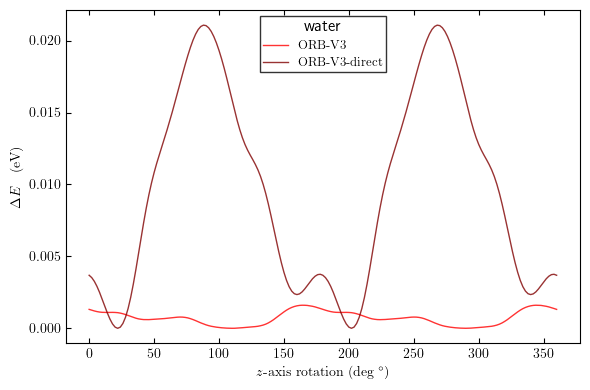

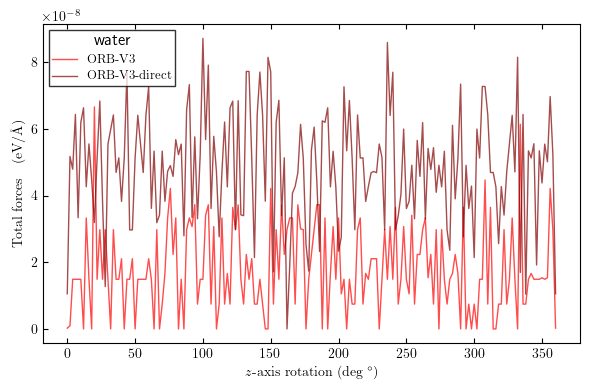

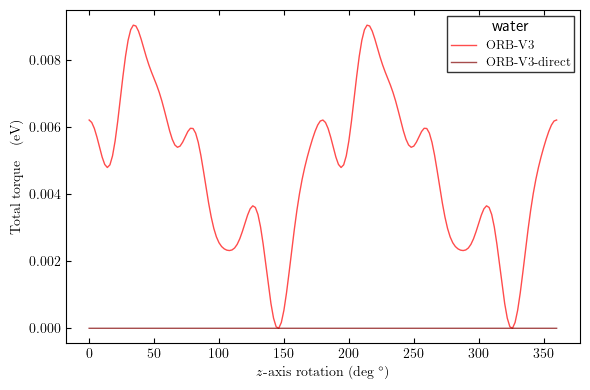

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


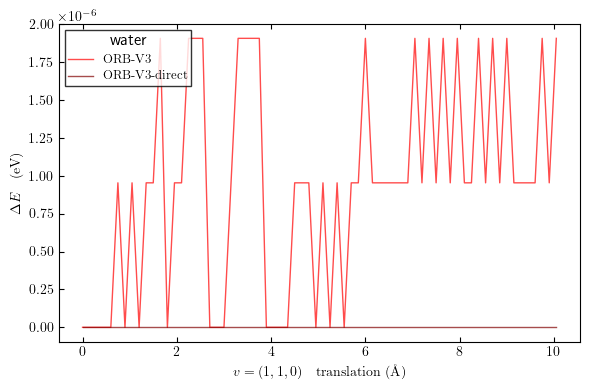

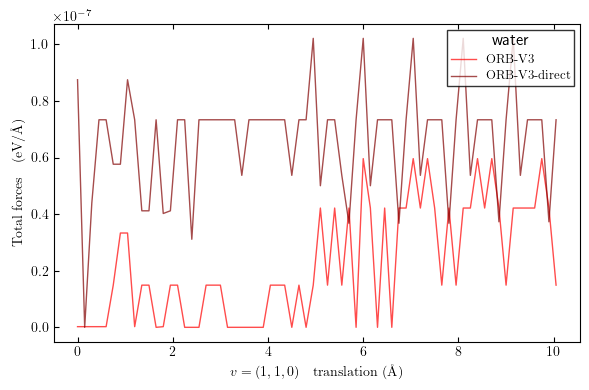

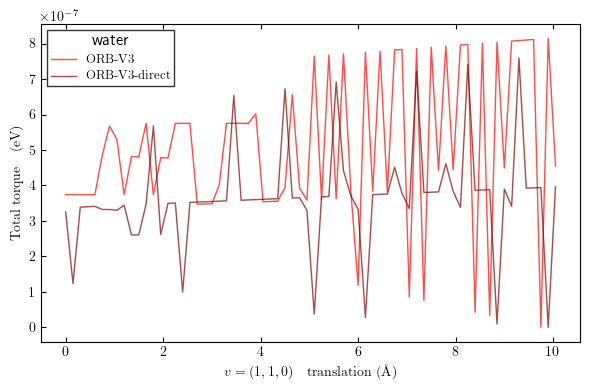

methane
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

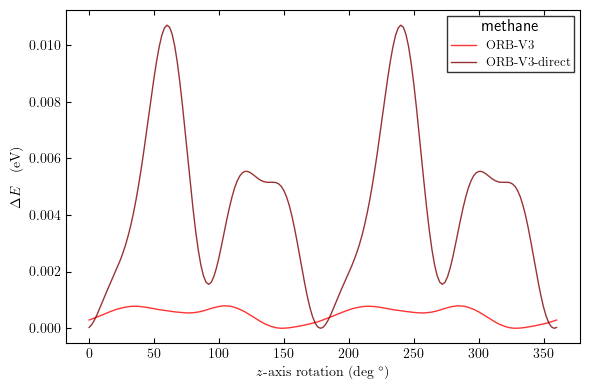

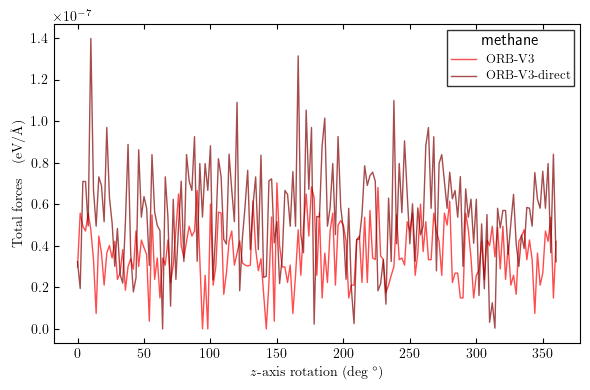

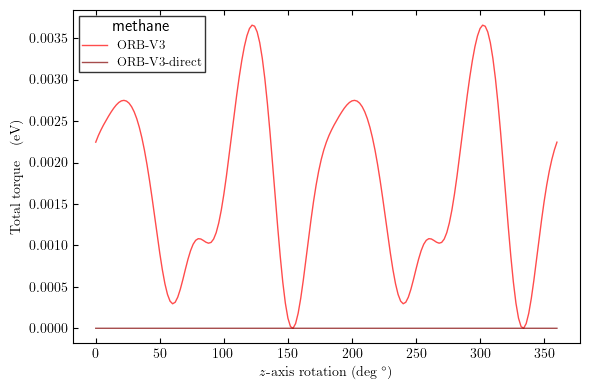

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


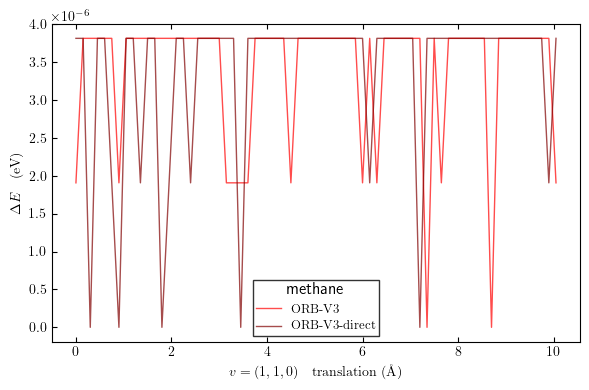

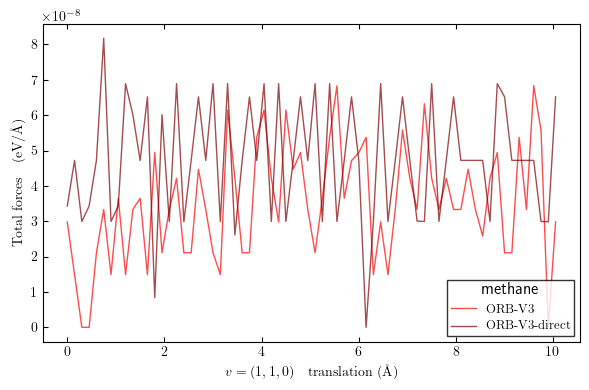

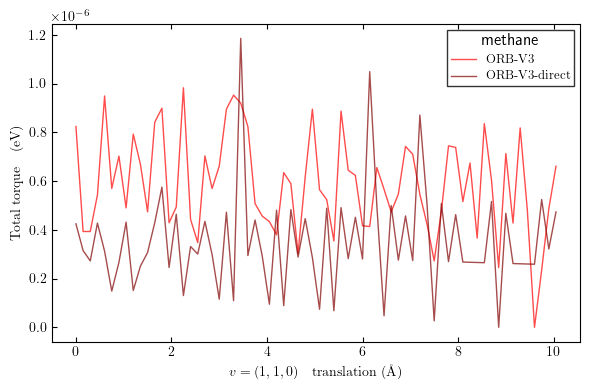

ammonia
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

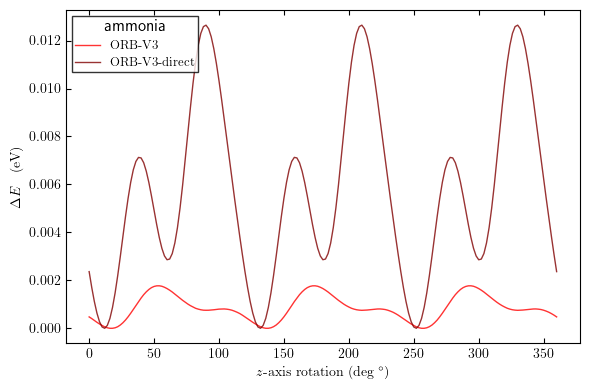

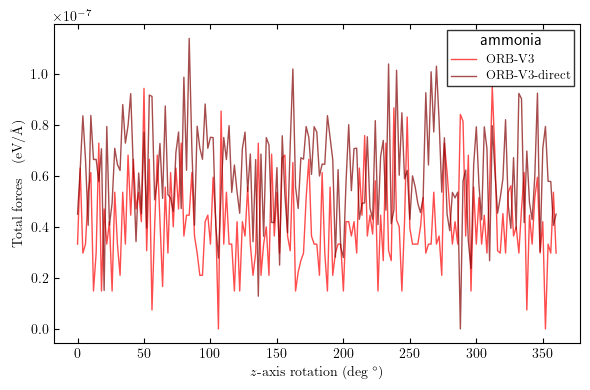

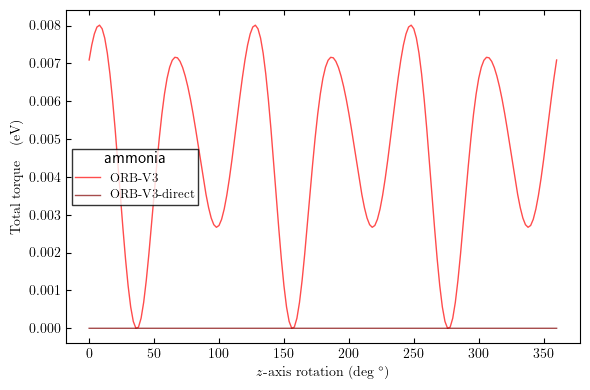

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


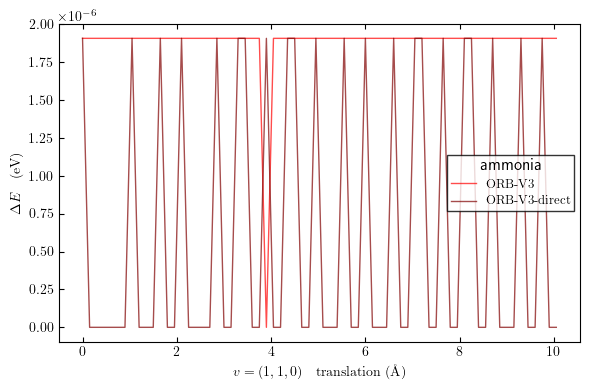

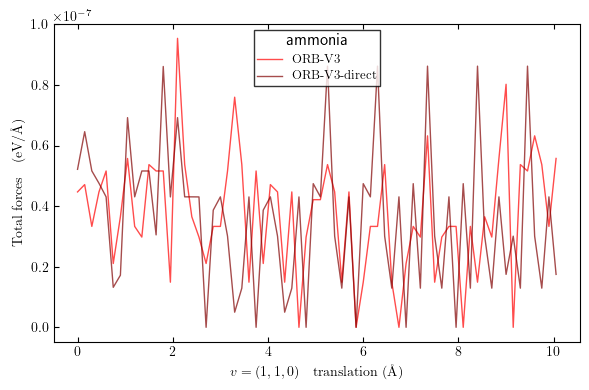

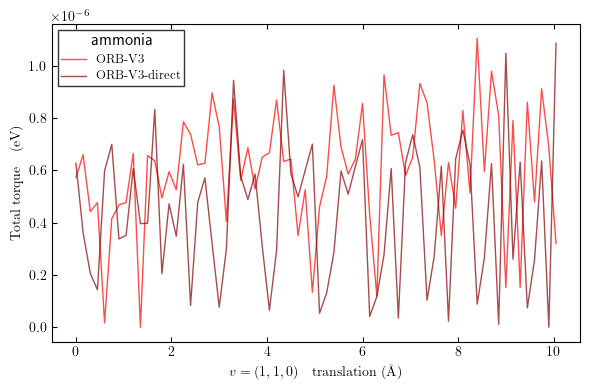

benzene
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

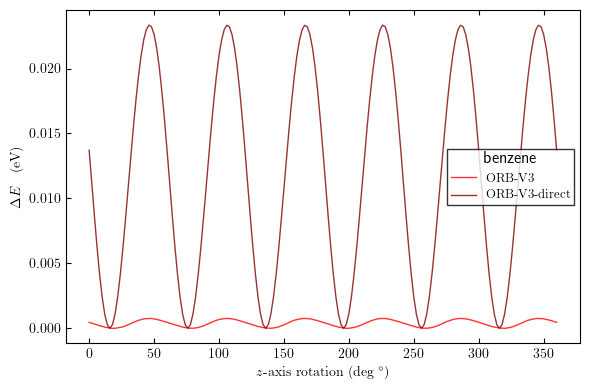

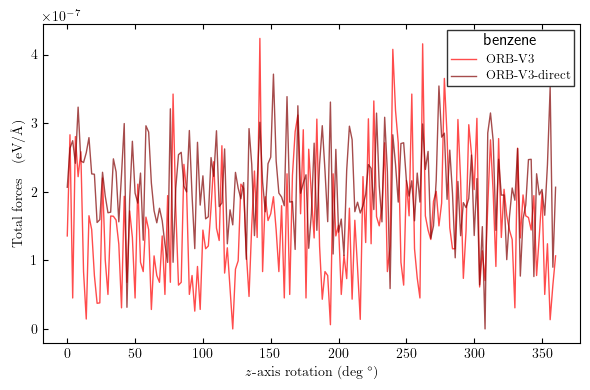

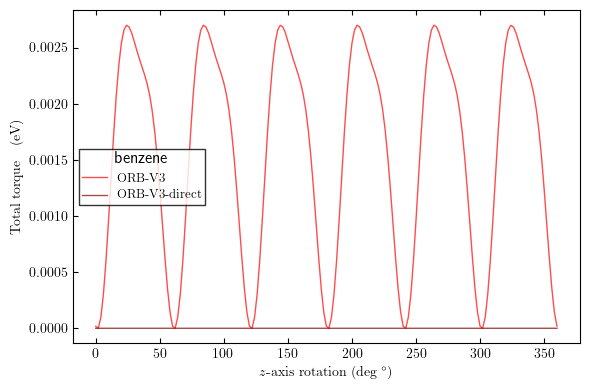

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


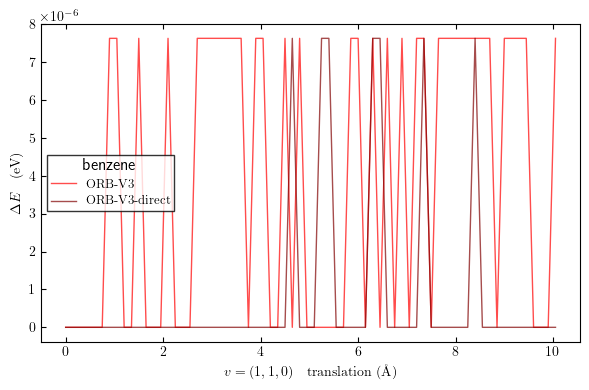

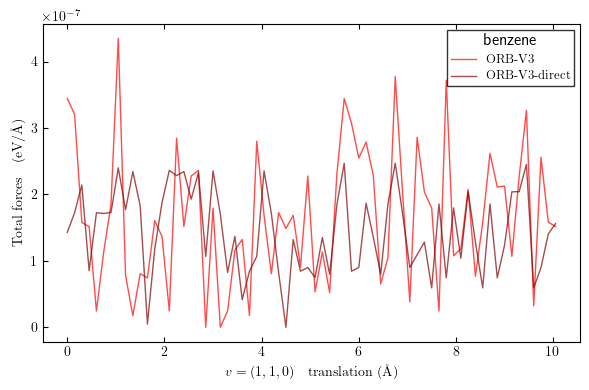

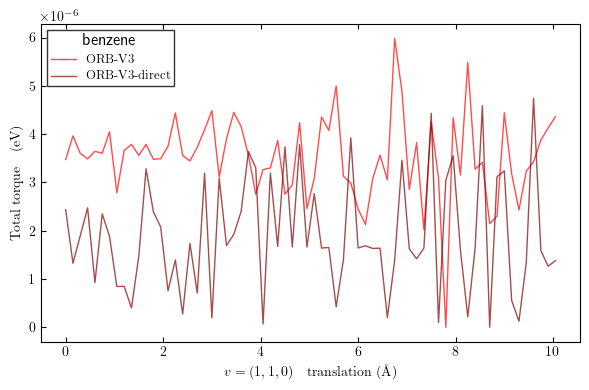

CO2
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360

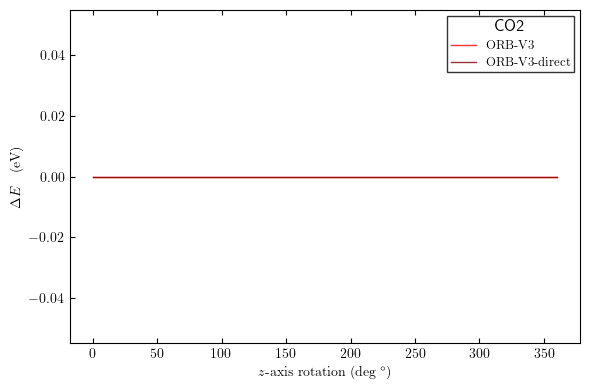

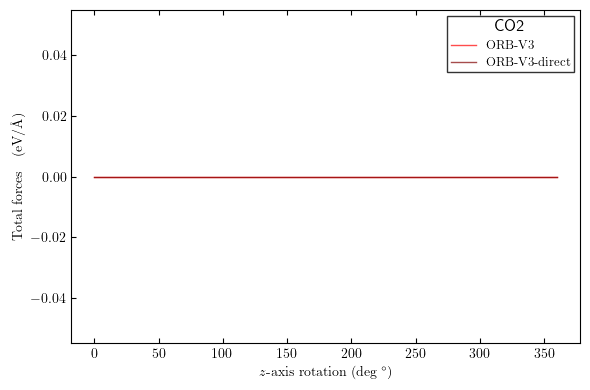

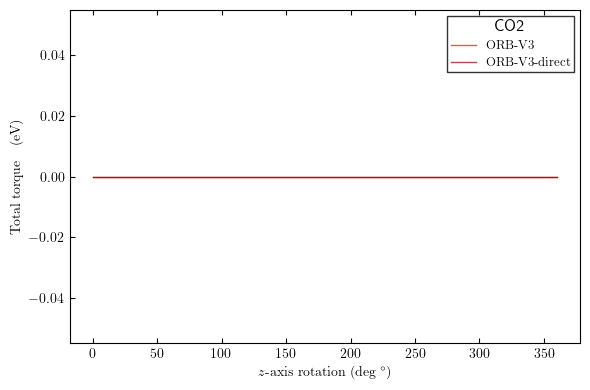

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


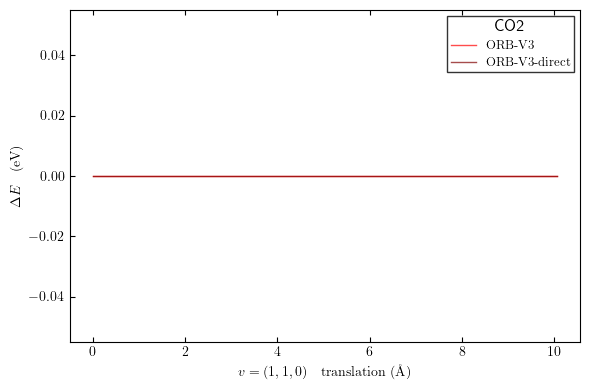

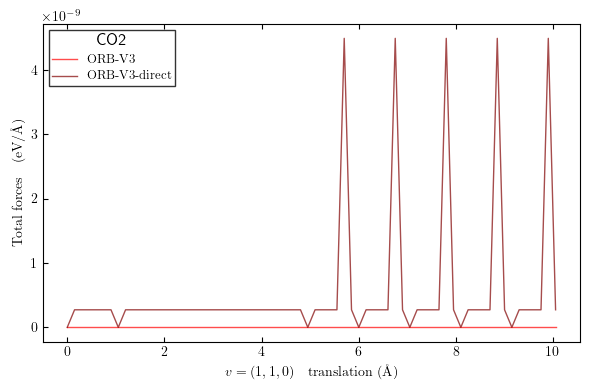

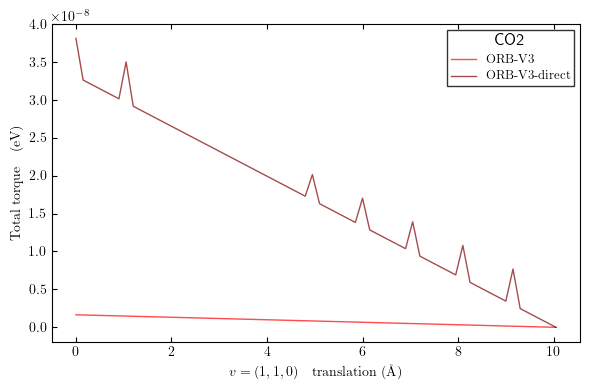

O2
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360.

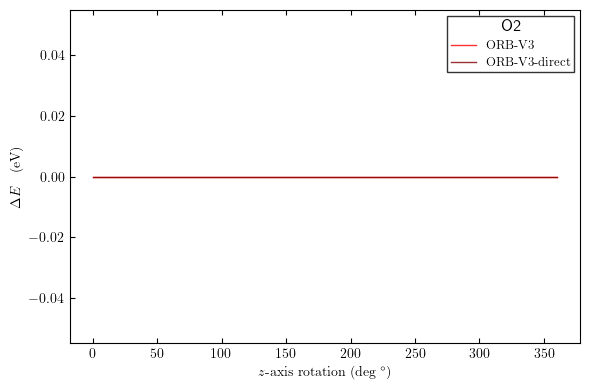

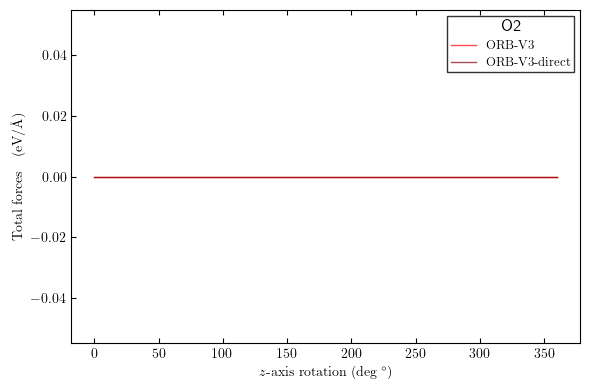

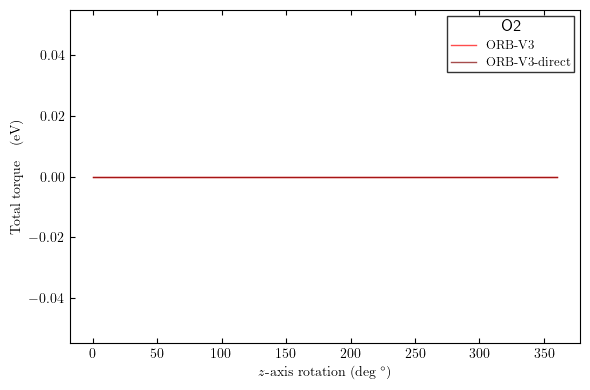

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


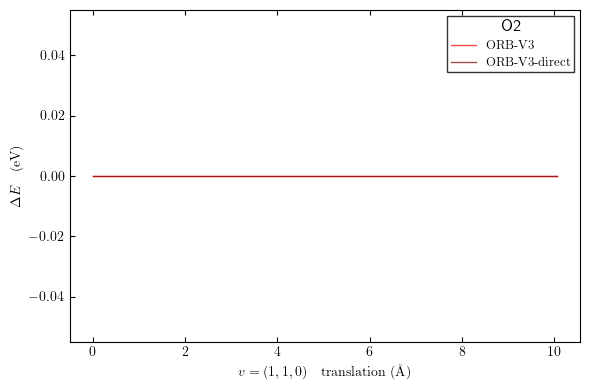

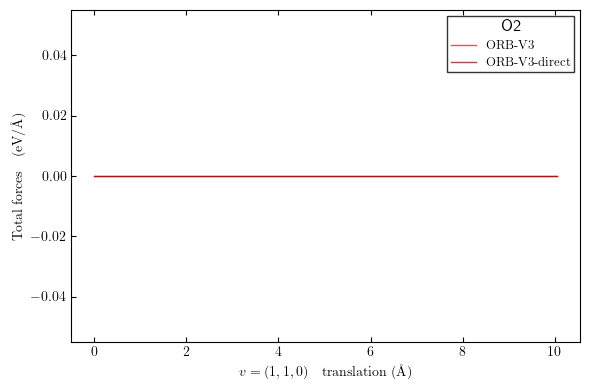

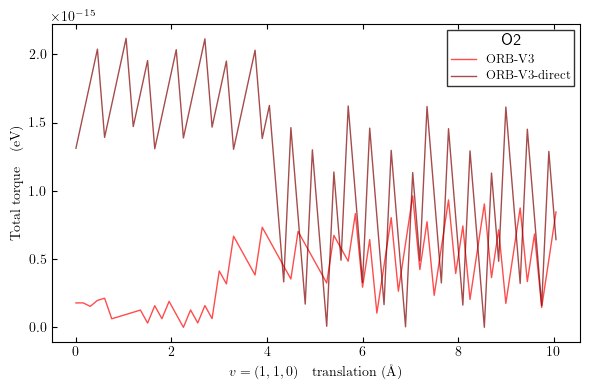

ethane
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 

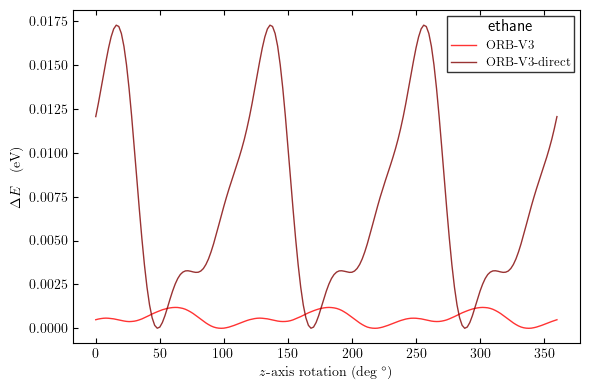

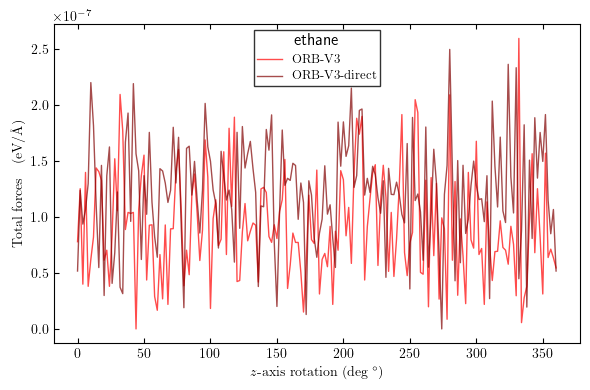

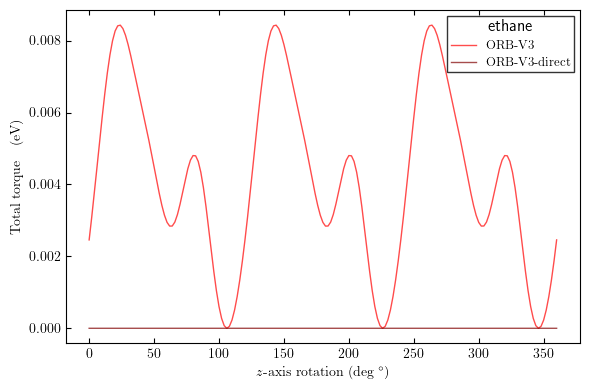

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


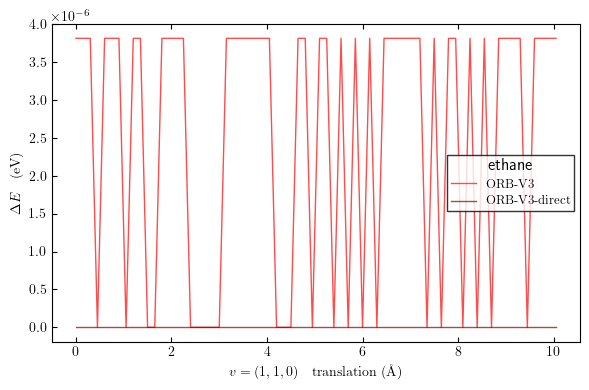

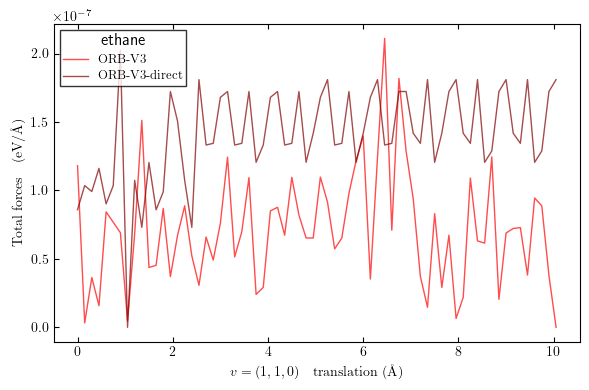

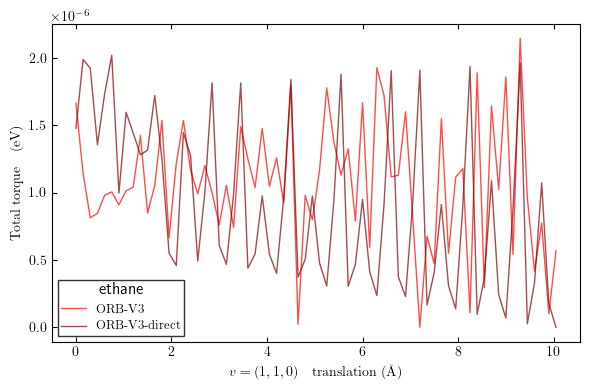

ethanol
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

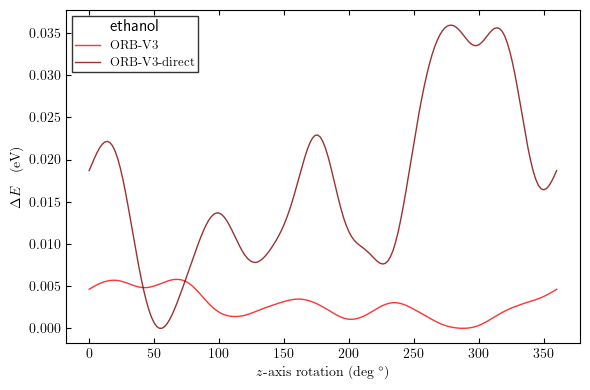

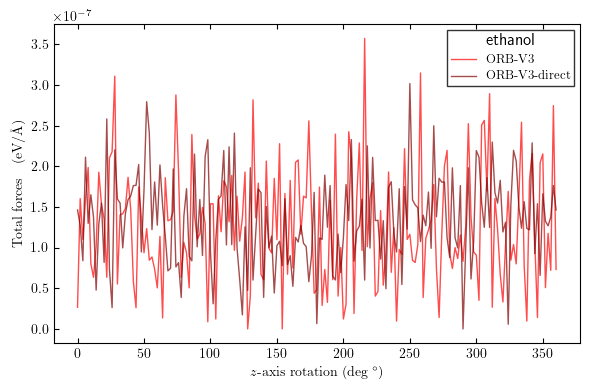

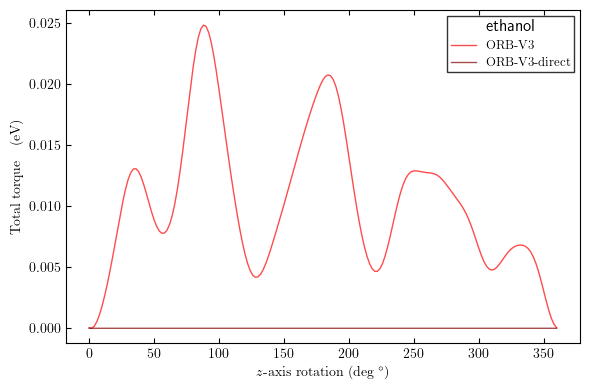

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


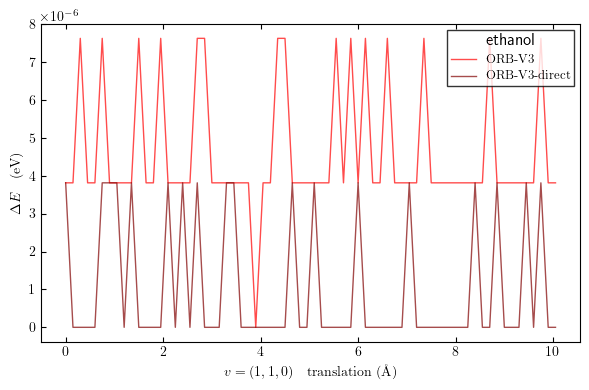

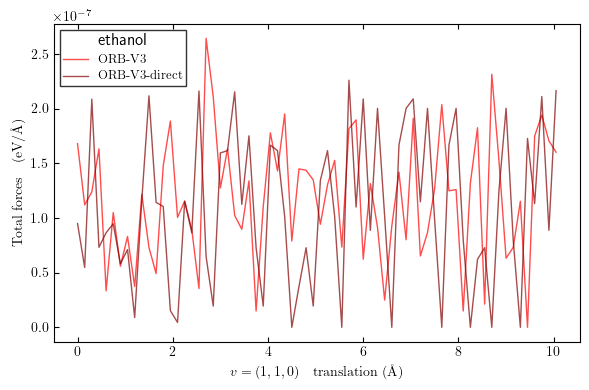

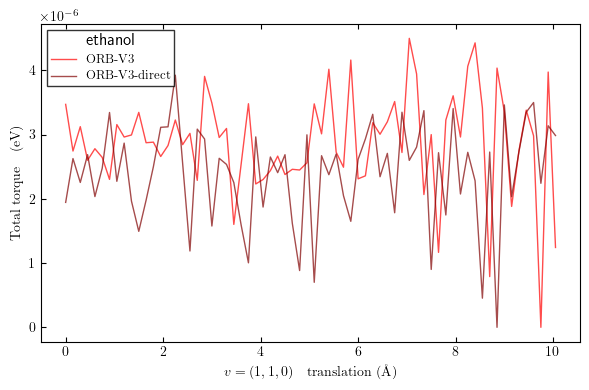

acetone
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

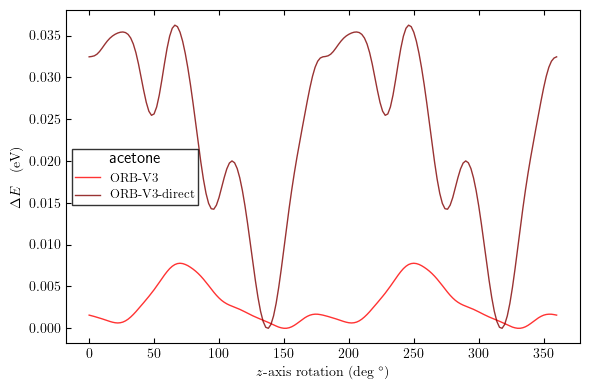

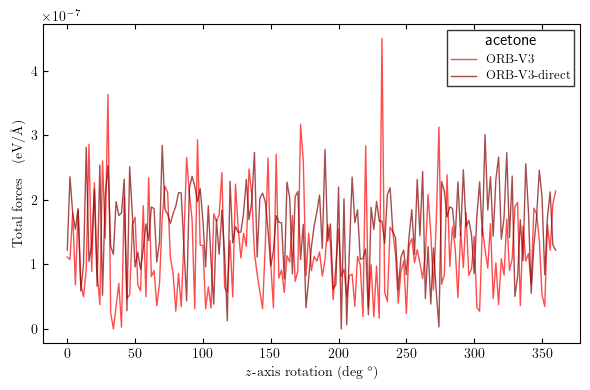

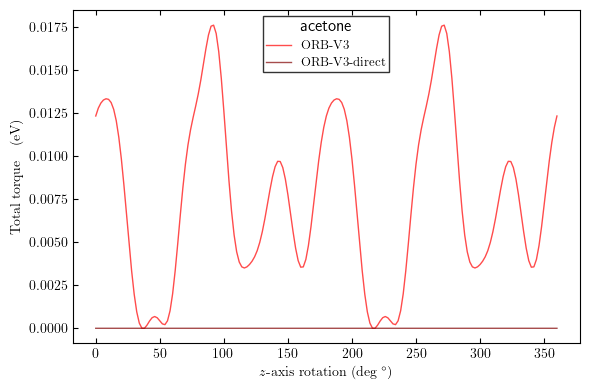

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


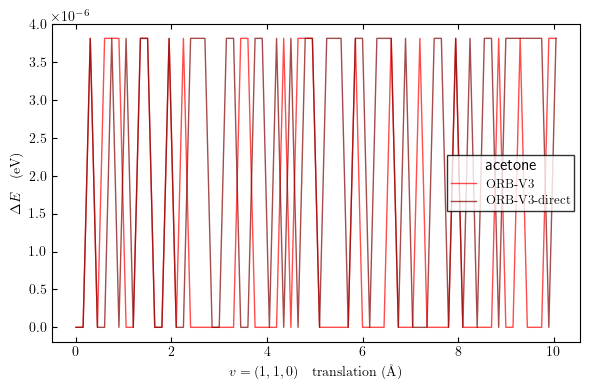

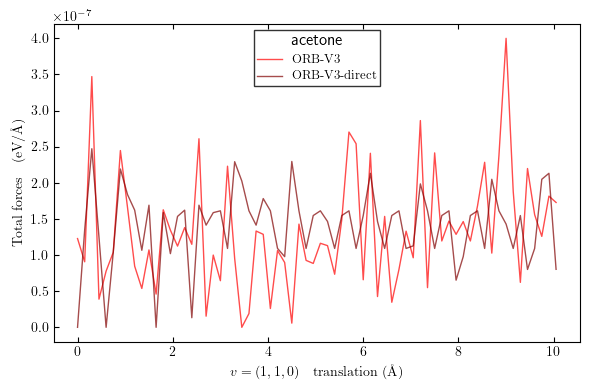

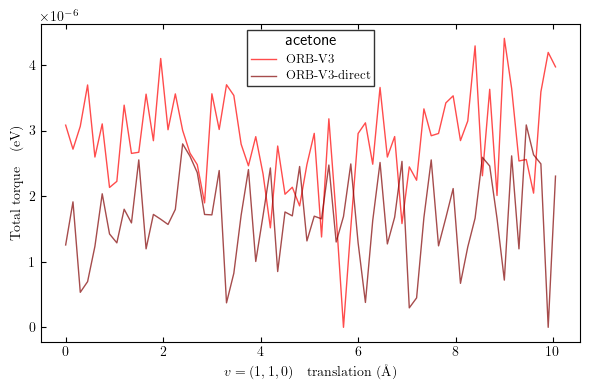

cyclobutadiene
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 35

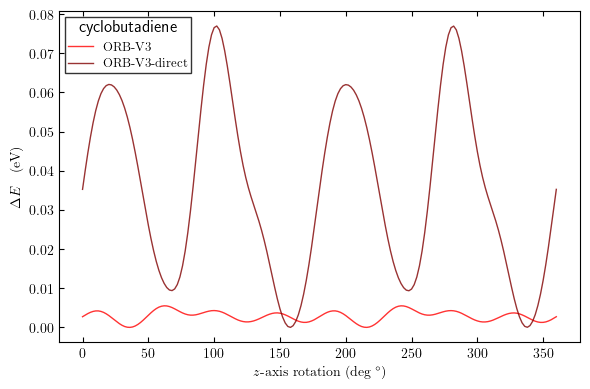

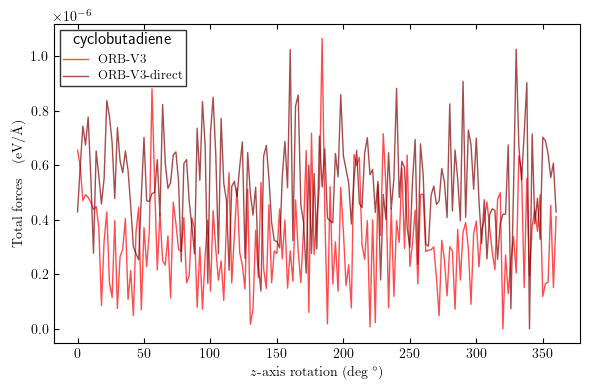

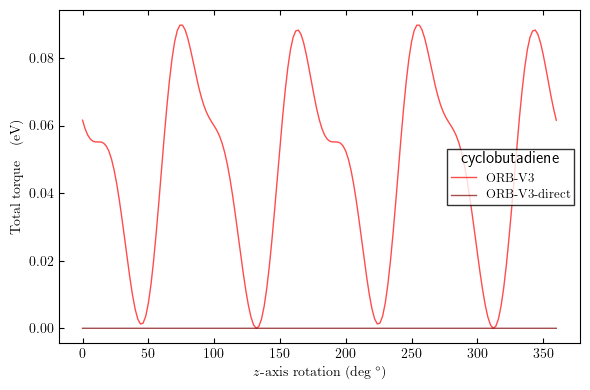

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 2 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
loading UMA


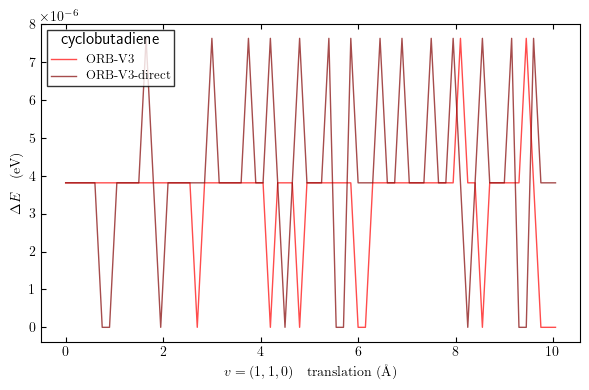

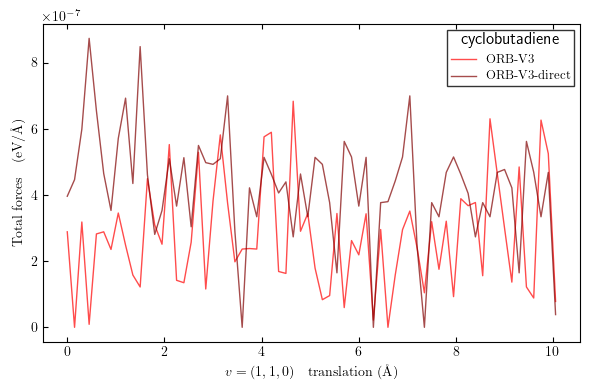

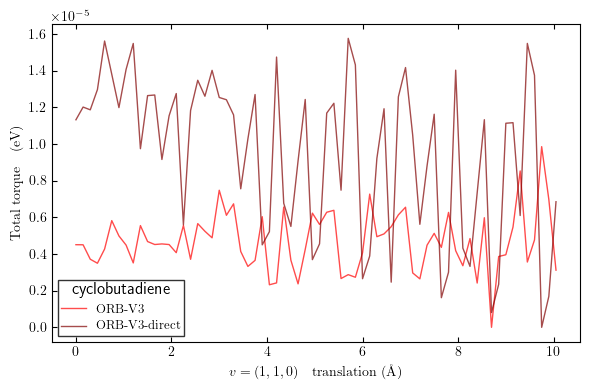

In [30]:
# molecule list (smiles)
#mol_string_list = ['ethane', 'benzene', 'CO2', 'cyclobutadiene', 'ethanol', 'O2', 'water', '2-propanol', 'acetone']

mol_string_list = [
    'water', 
    'methane', 
    'ammonia', 
    'benzene', 
    'CO2', 
    'O2', 
    'ethane', 
    'ethanol', 
    'acetone',
    'cyclobutadiene',
]

mol_ase_list = [
    build.molecule('H2O'), 
    build.molecule('CH4'),
    build.molecule('NH3'),
    build.molecule('C6H6'),
    build.molecule('CO2'),
    build.molecule('O2'),
    build.molecule('C2H6'),
    build.molecule('CH3CH2OH'),
    build.molecule('CH3COCH3'),
    pubchem_atoms_search(smiles='C1=CC=C1')
]


# use UMA for preprocessing
use_UMA = False
load_UMA = False

# translation options
trans_vector = (1,1,0)

# rotations are z-axis only
# as defined by ase.build.molecule

# fetch the molecule structures from pubchem via ASE
# use the first conformer/rotamer available in PubChem
#mol_ase_list = [pubchem_atoms_search(smiles=mol) for mol in mol_list]


# perform all the tests
for i in range(len(mol_ase_list)):
    evaluate_rotation(
        mol_ase_list[i], 
        calculator_list, 
        mol_name=mol_string_list[i], 
        calc_name=CALC_NAME, 
        resolution=2,
        visualize=False, 
        UMA=use_UMA,
        load_UMA=load_UMA,
        )

    evaluate_translation(
        mol_ase_list[i], 
        calculator_list, 
        mol_string_list[i], 
        calc_name=CALC_NAME, 
        trans_vector=trans_vector, 
        resolution=0.15, 
        search_space=[0, 10], 
        visualize=False, 
        UMA=use_UMA,
        load_UMA=load_UMA,
        )

    
    

## __FORCE TESTING__
Test whether the sum of the forces is zero along the transformation

## __TORQUE TESTING__
Test whether the sum of the torques is zero along the transformation